# Поведенческая сегментация пользователей стримингового сервиса (RFM)
### Полный пайплайн на «сыром» event-логе: профилирование → чистка → агрегация → сегментация

**Данные.** Сырой лог сессий `streaming_events_raw.csv` 

**Задача.** Выделить поведенческие сегменты и найти точки роста вовлечённости, отдельно —
пользователей, которые активны по входам, но не потребляют контент

**RFM в контексте стриминга:** Recency (давность последней сессии), Frequency (число сессий),
Monetary - Consumption (минуты просмотра)

**План:** 
1. Профилирование качества
2. Чистка данных
3. Агрегация в RFM-витрину
4. Фильтр ботов
5. EDA
6. RFM-скоринг и кластеризация
7. Сегменты
8. Гипотезы


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
plt.rcParams['font.family'] = 'DejaVu Sans'  
plt.rcParams['axes.unicode_minus'] = False     
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Загрузка и профилирование качества данных
Сначала смотрим, на первоначальные данные

In [3]:
raw = pd.read_csv("streaming_events_raw.csv")
print("Строк:", f"{len(raw):,}", " столбцов:", raw.shape[1])
raw.head(6)

Строк: 518,009  столбцов: 7


,event_id,user_id,session_start,watch_seconds,device,country,plan
0,347921,"111,313.00",2024-04-22 15:14:03,0.00,iOS,RU,premium
1,314360,"110,606.00",2024-04-17 22:46:23,0.00,Android,RU,premium
2,156119,"102,566.00",2024-04-10T09:54:44+03:00,"1,063.10",Smart TV,kz,free
3,328427,"110,899.00",2024-05-09 21:58:59,0.00,iOS,RU,premium
4,246043,"105,099.00",02/04/2024 21:55,"3,670.10",web,RU,free
5,304625,"110,401.00",2024-04-17 20:46:18,0.00,Android,Russia,free


In [3]:
# Профиль пропусков и типов
prof = pd.DataFrame({
    "dtype": raw.dtypes,
    "missing": raw.isna().sum(),
    "missing_%": (raw.isna().mean()*100).round(1),
    "n_unique": raw.nunique(),
})
print(prof)
print("\nПолных дубликатов событий (event_id):", raw.duplicated(subset="event_id").sum())

                 dtype  missing  missing_%  n_unique
event_id         int64        0       0.00    502921
user_id        float64    10360       2.00     12477
session_start      str     5180       1.00    469096
watch_seconds  float64    25260       4.90     74416
device             str    15540       3.00         8
country            str    15540       3.00         8
plan               str    15570       3.00         3

Полных дубликатов событий (event_id): 15088


In [4]:
# Аномалии во времени просмотра и в форматах дат
w = pd.to_numeric(raw["watch_seconds"], errors="coerce")
print("watch_seconds:")
print(f"  отрицательных:    {(w < 0).sum():,}")
print(f"  пропусков:        {w.isna().sum():,}")
print(f"  абсурдных (>4ч):  {(w > 4*3600).sum():,}  (max = {w.max():,.0f} сек)")
print("\nПримеры разных форматов даты:")
print(raw["session_start"].dropna().drop_duplicates().head(6).to_list())
print("Пустых строк-дат:", (raw["session_start"].astype(str).str.strip() == "").sum())

watch_seconds:
  отрицательных:    10,300
  пропусков:        25,260
  абсурдных (>4ч):  2,590  (max = 999,394 сек)

Примеры разных форматов даты:
['2024-04-22 15:14:03', '2024-04-17 22:46:23', '2024-04-10T09:54:44+03:00', '2024-05-09 21:58:59', '02/04/2024 21:55', '2024-04-17 20:46:18']
Пустых строк-дат: 0


Пустых строк-дат: 0


## 2. Чистка данных

Сначала отчистим дубликаты, далее невалидные данные. Каждый шаг отлогируем чтобы видеть потери

In [6]:
log = []
def step(df, name):
    log.append((name, len(df)))
    return df

df = step(raw.copy(), "0. сырые данные")
df = step(df.drop_duplicates(subset="event_id"), "1. дедуп событий")
df = step(df.dropna(subset=["user_id"]), "2. убраны null user_id")
df["user_id"] = df["user_id"].astype(int)

In [7]:
def parse_dates(col):
    s = col.astype(str).str.strip()
    dt = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    iso = s.str.match(r"^\d{4}-\d{2}-\d{2}")          # 2024-03-01 ... и ...T..+03:00
    dt.loc[iso] = pd.to_datetime(s[iso], errors="coerce", utc=True).dt.tz_localize(None)
    sl = s.str.contains("/")                           # 01/03/2024 14:22
    dt.loc[sl] = pd.to_datetime(s[sl], format="%d/%m/%Y %H:%M", errors="coerce")
    return dt

df["ts"] = parse_dates(df["session_start"])
print("Не распарсилось (пустые/битые):", df["ts"].isna().sum())
df = step(df.dropna(subset=["ts"]), "3. распарсены даты")
print("Период наблюдения:", df.ts.min().date(), "—", df.ts.max().date())

Не распарсилось (пустые/битые): 14696
Период наблюдения: 2024-03-01 — 2024-05-23


In [9]:
w = pd.to_numeric(df["watch_seconds"], errors="coerce").mask(lambda x: x < 0)
cap = np.nanpercentile(w[w > 0], 99)
print(f"99-й перцентиль = {cap/60:.0f} мин, обрезаем выбросы по нему")
df["watch_min"] = w.clip(upper=cap).fillna(0) / 60.0   # пропуск/невалид = 0 минут просмотра

# 5. Категориальные: регистр и пробелы
df["device"]  = (df["device"].astype(str).str.strip().str.lower()
                   .replace({"smarttv": "smart tv", "nan": np.nan}))
df["country"] = (df["country"].astype(str).str.strip().str.lower()
                   .replace({"russia": "ru", "russian federation": "ru",
                             "uzbekistan": "uz", "nan": np.nan}))
df = step(df, "4-5. очищены watch и категории")

clean_log = pd.DataFrame(log, columns=["шаг", "строк"])
clean_log["потеряно"] = clean_log["строк"].diff().fillna(0).astype(int)
print(clean_log.to_string(index=False))

99-й перцентиль = 240 мин, обрезаем выбросы по нему
                           шаг  строк  потеряно
               0. сырые данные 518009         0
              1. дедуп событий 502921    -15088
        2. убраны null user_id 492832    -10089
            3. распарсены даты 478136    -14696
4-5. очищены watch и категории 478136         0
4-5. очищены watch и категории 478136         0


                           шаг  строк  потеряно
               0. сырые данные 518009         0
              1. дедуп событий 502921    -15088
        2. убраны null user_id 492832    -10089
            3. распарсены даты 478136    -14696
4-5. очищены watch и категории 478136         0


## 3. Агрегация в RFM-витрину

Сворачиваем события в пользовательский уровень. В продакшене это делается на стороне
PostgreSQL эквивалентный запрос:

```sql
WITH s AS (
    SELECT user_id,
           MAX(session_start)                                AS last_session,
           COUNT(*)                                          AS frequency,
           SUM(LEAST(watch_seconds, 14400)) / 60.0           AS watch_minutes,
           COUNT(DISTINCT date_trunc('week', session_start)) AS active_weeks
    FROM streaming_sessions
    WHERE watch_seconds >= 0
    GROUP BY user_id
)
SELECT user_id,
       (CURRENT_DATE - last_session::date) AS recency_days,
       frequency, watch_minutes,
       ROUND(active_weeks::numeric / 12, 3) AS retention_rate
FROM s;
```

In [10]:
NOW = df.ts.max()
total_weeks = df.ts.dt.to_period("W").nunique()
users = df.groupby("user_id").agg(
    recency_days  = ("ts", lambda s: (NOW - s.max()).days),
    frequency     = ("event_id", "size"),
    watch_minutes = ("watch_min", "sum"),
    med_watch     = ("watch_min", "median"),
    active_weeks  = ("ts", lambda s: s.dt.to_period("W").nunique()),
)
users["retention_rate"] = (users["active_weeks"] / total_weeks).round(3)
print("Пользователей в витрине:", f"{len(users):,}")
print(users[["recency_days","frequency","watch_minutes","retention_rate"]].describe().round(1).T)

Пользователей в витрине: 12,475
                   count     mean      std  min    25%    50%      75%  \
recency_days   12,475.00    14.10    18.90 0.00   0.00   7.00    21.00   
frequency      12,475.00    38.30    59.00 1.00   8.00  32.00    48.00   
watch_minutes  12,475.00 1,017.70 1,300.40 0.00 136.50 310.40 1,513.50   
retention_rate 12,475.00     0.60     0.30 0.10   0.30   0.60     0.80   

                    max  
recency_days      83.00  
frequency        575.00  
watch_minutes  6,210.00  
retention_rate     1.00  


## 4. Фильтрация ботов / не-людей

Часть пользователей является ботами: сотни сессий за 90 дней при нулевом просмотре. По сумме/среднему просмотра их не поймать, впрыснутые выбросы времени их зашумляют.
Надёжным признаком является аномальная частота (>150 сессий) при медианном
просмотре 0

In [11]:
bot_mask = (users["frequency"] > 150) & (users["med_watch"] < 1)
bots = users[bot_mask]
print(f"Найдено ботов: {len(bots)}")
print(f"  медиана частоты у ботов: {bots.frequency.median():.0f} сессий")
print(f"  медиана просмотра:       {bots.med_watch.median():.1f} мин/сессия")
users = users[~bot_mask].drop(columns="med_watch")
print(f"\nЧистая база людей: {len(users):,}")

Найдено ботов: 280
  медиана частоты у ботов: 372 сессий
  медиана просмотра:       0.0 мин/сессия

Чистая база людей: 12,195


## 5. EDA

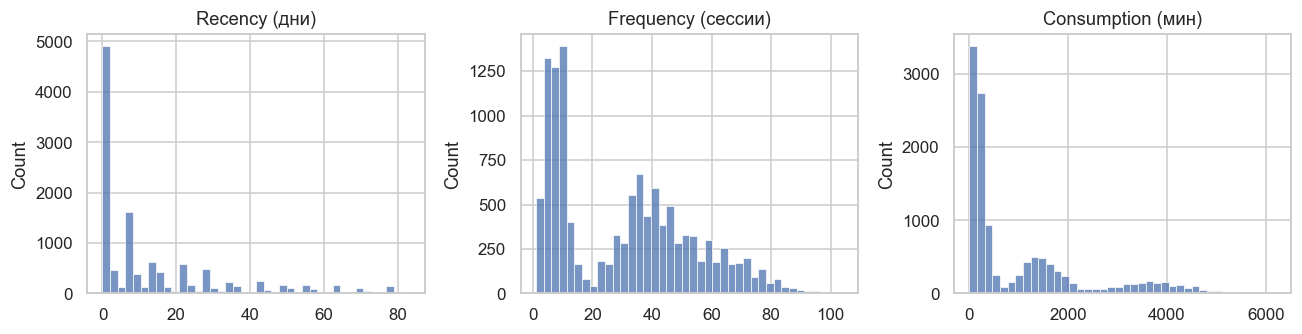

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
for a, c, t in zip(ax, ["recency_days","frequency","watch_minutes"],
                    ["Recency (дни)","Frequency (сессии)","Consumption (мин)"]):
    sns.histplot(users[c], bins=40, ax=a, color="#4C72B0"); a.set_title(t); a.set_xlabel("")
plt.tight_layout(); plt.show()

Корреляция Пирсона (frequency ~ retention): r = 0.91


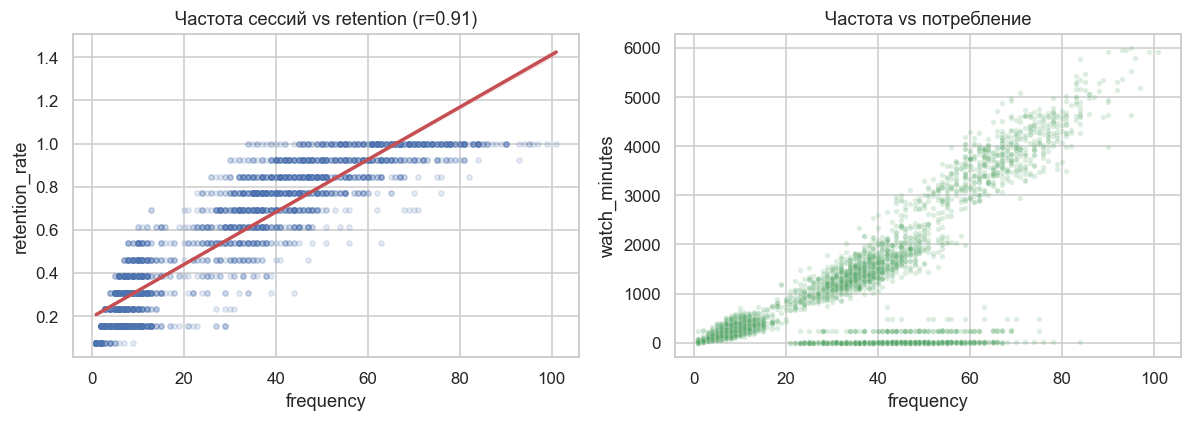

In [13]:
r, p = stats.pearsonr(users["frequency"], users["retention_rate"])
print(f"Корреляция Пирсона (frequency ~ retention): r = {r:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.regplot(data=users.sample(3000, random_state=1), x="frequency", y="retention_rate",
            scatter_kws=dict(alpha=.15,s=12,color="#4C72B0"), line_kws=dict(color="#C44E52"), ax=ax[0])
ax[0].set_title(f"Частота сессий vs retention (r={r:.2f})")
sns.scatterplot(data=users.sample(4000, random_state=1), x="frequency", y="watch_minutes",
                alpha=.2, s=12, color="#55A868", ax=ax[1])
ax[1].set_title("Частота vs потребление")
plt.tight_layout(); plt.show()

Частота входов почти линейно предсказывает retention (r ≈ 0.9), но на правом графике видно расслоение: есть пользователи с высокой частотой и нулевым просмотром, здесь обычная retention-метрика их не отлавливает

## 6. RFM-скоринг и кластеризация

In [14]:
users["R_score"] = pd.qcut(users["recency_days"].rank(method="first"), 5, labels=[5,4,3,2,1]).astype(int)
users["F_score"] = pd.qcut(users["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
users["M_score"] = pd.qcut(users["watch_minutes"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
print(users[["recency_days","R_score","frequency","F_score","watch_minutes","M_score"]].head())

         recency_days  R_score  frequency  F_score  watch_minutes  M_score
user_id                                                                   
100001              0        5         77        5       4,732.30        5
100002              0        5         89        5       4,876.32        5
100003              0        5         82        5       4,624.39        5
100004              1        4         57        5       2,865.53        5
100005              3        3         50        4       2,099.20        5


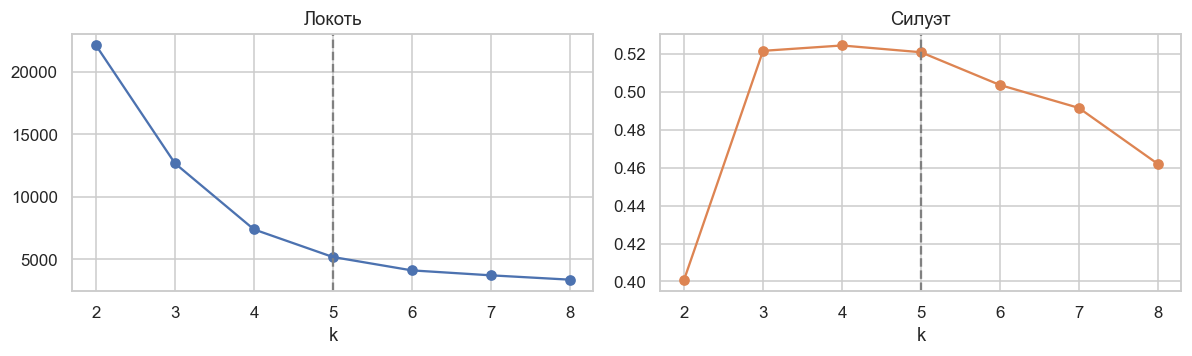

k=5 — баланс качества и интерпретируемости.


In [15]:
X = users[["recency_days","frequency","watch_minutes"]].copy()
X["watch_minutes"] = np.log1p(X["watch_minutes"])
Xs = StandardScaler().fit_transform(X)

Ks = range(2, 9); inertia=[]; sil=[]
for k in Ks:
    m = KMeans(k, n_init=10, random_state=11).fit(Xs)
    inertia.append(m.inertia_); sil.append(silhouette_score(Xs, m.labels_))
fig, ax = plt.subplots(1,2, figsize=(11,3.4))
ax[0].plot(list(Ks), inertia, "o-", color="#4C72B0"); ax[0].axvline(5, ls="--", color="grey"); ax[0].set_title("Локоть"); ax[0].set_xlabel("k")
ax[1].plot(list(Ks), sil, "o-", color="#DD8452"); ax[1].axvline(5, ls="--", color="grey"); ax[1].set_title("Силуэт"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.show()
print("k=5 — баланс качества и интерпретируемости.")

In [16]:
users["cluster"] = KMeans(5, n_init=10, random_state=11).fit_predict(Xs)
prof = users.groupby("cluster").agg(
    users=("frequency","size"), recency=("recency_days","mean"),
    frequency=("frequency","mean"), consumption=("watch_minutes","mean"),
    retention=("retention_rate","mean"))
prof["share_%"] = (prof["users"]/len(users)*100).round(1)
print(prof.round(1))

         users  recency  frequency  consumption  retention  share_%
cluster                                                            
0         3395    13.10       8.30       247.30       0.30    27.80
1         1887    52.50       8.00       247.50       0.20    15.50
2         1742     1.60      68.40     3,709.60       1.00    14.30
3         1782     5.50      44.80         3.60       0.80    14.60
4         3389     5.80      38.10     1,413.00       0.70    27.80


### Именование сегментов по профилю (детерминированно)

In [17]:
pp = prof.copy(); names = {}
names[pp["consumption"].idxmin()] = "Спящие"; pp = pp.drop(pp["consumption"].idxmin())
names[pp["recency"].idxmax()]     = "Уходящие (at-risk)"; pp = pp.drop(pp["recency"].idxmax())
names[pp["consumption"].idxmax()] = "Ядро (champions)"; pp = pp.drop(pp["consumption"].idxmax())
names[pp["frequency"].idxmin()]   = "Случайные/новички"; pp = pp.drop(pp["frequency"].idxmin())
names[pp.index[0]] = "Лояльные"
users["segment"] = users["cluster"].map(names)

order = ["Ядро (champions)","Лояльные","Случайные/новички","Спящие","Уходящие (at-risk)"]
summary = (users.groupby("segment")
           .agg(users=("frequency","size"), recency=("recency_days","mean"),
                frequency=("frequency","mean"), consumption=("watch_minutes","mean"),
                retention=("retention_rate","mean")).reindex(order))
summary["share_%"] = (summary["users"]/len(users)*100).round(1)
print(summary.round(1))

                    users  recency  frequency  consumption  retention  share_%
segment                                                                       
Ядро (champions)     1742     1.60      68.40     3,709.60       1.00    14.30
Лояльные             3389     5.80      38.10     1,413.00       0.70    27.80
Случайные/новички    3395    13.10       8.30       247.30       0.30    27.80
Спящие               1782     5.50      44.80         3.60       0.80    14.60
Уходящие (at-risk)   1887    52.50       8.00       247.50       0.20    15.50


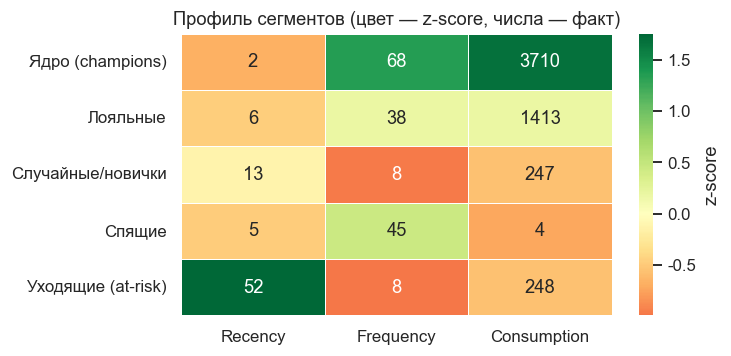

In [18]:
heat = summary[["recency","frequency","consumption"]]
heat_z = (heat - heat.mean())/heat.std()
heat_z.columns = ["Recency","Frequency","Consumption"]
plt.figure(figsize=(6.8,3.4))
sns.heatmap(heat_z, annot=heat.round(0).values, fmt=".0f", cmap="RdYlGn", center=0,
            cbar_kws={"label":"z-score"}, linewidths=.6)
plt.title("Профиль сегментов (цвет — z-score, числа — факт)"); plt.ylabel(""); plt.tight_layout(); plt.show()

## 7. Сегмент «Спящие»

Заходят часто (частота на уровне лояльных), но почти ничего не смотрят. По login-retention выглядят здоровыми, обычная метрика удержания их не видит. Это скрытый отток

Спящие: 15% аудитории
  частота (медиана):  45  (лояльные: 38)
  просмотр (медиана): 3.4 мин
  login-retention:    0.78  — как у активных
  доля с <30 мин:     100%


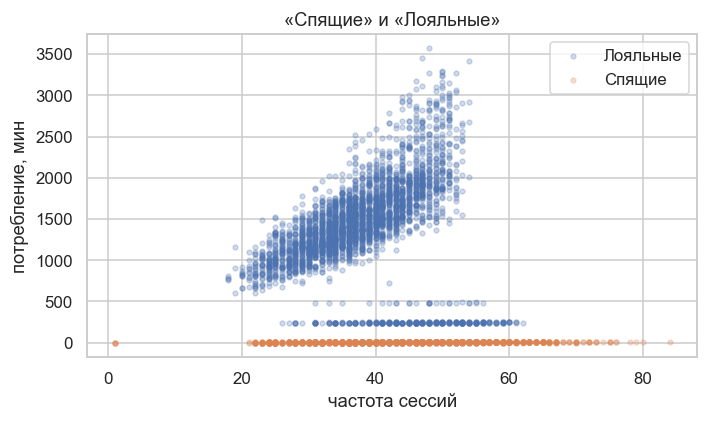

In [20]:
sl = users[users.segment=="Спящие"]; ly = users[users.segment=="Лояльные"]
print(f"Спящие: {len(sl)/len(users):.0%} аудитории")
print(f"  частота (медиана):  {sl.frequency.median():.0f}  (лояльные: {ly.frequency.median():.0f})")
print(f"  просмотр (медиана): {sl.watch_minutes.median():.1f} мин")
print(f"  login-retention:    {sl.retention_rate.mean():.2f}  — как у активных")
print(f"  доля с <30 мин:     {(sl.watch_minutes < 30).mean():.0%}")

fig, ax = plt.subplots(figsize=(6.6,4))
for seg,c in [("Лояльные","#4C72B0"),("Спящие","#DD8452")]:
    d = users[users.segment==seg]
    ax.scatter(d.frequency, d.watch_minutes, s=10, alpha=.25, color=c, label=seg)
ax.set_xlabel("частота сессий"); ax.set_ylabel("потребление, мин")
ax.set_title("«Спящие» и «Лояльные»")
ax.legend(); plt.tight_layout(); plt.show()

## 8. Выводы и рекомендации

**Качество данных.** Из сырого лога убрано: дубликаты событий, ~2% строк без `user_id`, ~3% с непарсящимися датами; время просмотра винзоризовано по 99-му перцентилю; отдельно отфильтрованы **боты** (>150 сессий при нулевом просмотре) иначе они искажали бы сегменты. Отдельная находка: глобальный `dayfirst` ломал ISO-даты, форматы пришлось парсить раздельно.

**Сегменты.** Выделено 5 устойчивых групп. Ключевой сегмент это «спящие» : высокая частота входов при просмотре ≈ 0. Их login-retention высокий, поэтому стандартная метрика удержания маскирует проблему, это скрытый отток.

**Связь метрик.** Частота сессий сильно коррелирует с retention (r ≈ 0.9), но **частота ≠ потребление**: у «спящих» поведение расходится, и работать с ними нужно отдельной механикой.

**Гипотезы по вовлечению (приоритет группа «Спящие»)**
1. **Редизайн точек входа.** Частые входы при нулевом просмотре является признаком фрикции на старте: пользователь открывает приложение, не находит, что смотреть, и уходит. Гипотеза: персонализация главного экрана («продолжить просмотр», подборки «для вас») повысит конверсию входа в просмотр. Проверка: A/B на сегменте «Спящие».

2. **Контентные пуш-уведомления** (не «зайдите», а «вышел новый эпизод сериала, который вы начали»):   цель - превратить вход в реальный просмотр.

**По остальным сегментам:** «Ядро»: программа лояльности; 
«Лояльные» - расширение жанров и апсейл;
«Случайные/новички» - онбординг первых 7 дней;
«Уходящие» - win-back с низким приоритетом.

**Метрический вывод.** Login-retention переоценивает здоровье части базы. Рекомендуется ввести **consumption-retention** (доля недель с реальным просмотром) как основную метрику удержания.
